In [1]:
# import coiled

# cluster = coiled.Cluster(
#    name="demo-region",
#    n_workers=1,
#    region="us-west-2",
#    worker_vm_types="r8g.2xlarge",
#    scheduler_vm_types="r8g.2xlarge",
# )

# client = cluster.get_client()

In [2]:
import duckdb
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import xarray as xr
from ibicus.debias import QuantileMapping

In [3]:
from srm import downscaling_utils

# Get data

In [4]:
RUN_PARAMETERS = {
    "OBS": "ERA5",
    "GCM": "CESM2-WACCM",
    "TRAIN_PERIOD_START": 1978,
    "TRAIN_PERIOD_END": 2014,
    "PREDICT_PERIOD_START": 2015,
    "PREDICT_PERIOD_END": 2100,
    "VAR": "tas",
}

In [5]:
ssp245 = downscaling_utils.get_experiment(
    gcm=RUN_PARAMETERS["GCM"], scenario="SSP245", var=RUN_PARAMETERS["VAR"]
)
ssp245 = ssp245.isel(ensemble_member=0)

model_historical = downscaling_utils.get_experiment(
    gcm=RUN_PARAMETERS["GCM"], scenario="Historical", var=RUN_PARAMETERS["VAR"]
)

In [6]:
era5 = downscaling_utils.get_obs(var=RUN_PARAMETERS["VAR"])

In [7]:
df = duckdb.sql(
    """install httpfs; load httpfs; install spatial; load spatial; SELECT name, ST_AsText(geom) as geometry FROM ST_Read('https://carbonplan-data.s3.us-west-2.amazonaws.com/countries-50m.json') WHERE NAME = 'Finland'"""
).df()
df["geometry"] = gpd.GeoSeries.from_wkt(df["geometry"])
subset_geom = gpd.GeoDataFrame(df, geometry="geometry")

lon_min, lat_min, lon_max, lat_max = subset_geom.total_bounds
lon_min = lon_min - 2
lon_max = lon_max + 2
lat_min = lat_min - 2
lat_max = lat_max + 2

### Subset data to demo region (Finland)

In [8]:
era5_subset_bounds = downscaling_utils.subset_space(
    era5, coord_bounds_list=[lat_min - 1, lat_max + 1, lon_min - 1, lon_max + 1]
)

model_historical_subset_bounds = downscaling_utils.subset_space(
    model_historical, coord_bounds_list=[lat_min, lat_max, lon_min, lon_max]
)

ssp245_subset_bounds = downscaling_utils.subset_space(
    ssp245, coord_bounds_list=[lat_min, lat_max, lon_min, lon_max]
)

In [9]:
dict_all = {
    "ssp245": ssp245_subset_bounds,
    "model_hist": model_historical_subset_bounds,
    "era5": era5_subset_bounds,
}

# Preprocess data

### Calculate coarse version of high-res observational dataset
(this is an imprecise linear interpolation -- need to change to area averaging)

In [10]:
dict_all["era5_coarse"] = downscaling_utils.interpolate_to_coarse_grid(
    da_fine_to_coarsen=dict_all["era5"], da_coarse_grid=dict_all["ssp245"]
)

### Concatenate historical and future scenario
This is necessary for calculating the 9-year rolling average when detrending

In [11]:
dict_all["historical_ssp"] = xr.concat(
    [
        dict_all["model_hist"].where(
            dict_all["model_hist"]["time.year"] < RUN_PARAMETERS["PREDICT_PERIOD_START"],
            drop=True,
        ),
        dict_all["ssp245"].where(
            dict_all["ssp245"]["time.year"] >= RUN_PARAMETERS["PREDICT_PERIOD_START"],
            drop=True,
        ),
    ],
    dim="time",
)

### Detrend future scenario data

In [12]:
da_baseline_clim = downscaling_utils.calculate_baseline_climatology(
    da_baseline=dict_all["model_hist"],
    baseline_period_start=RUN_PARAMETERS["TRAIN_PERIOD_START"],
    baseline_period_end=RUN_PARAMETERS["TRAIN_PERIOD_END"],
)

ssp_detrended, ssp_trend_on_daily_timestep = downscaling_utils.detrend(
    da=dict_all["historical_ssp"].drop_vars("spatial_ref", errors="ignore"),
    da_baseline_clim=da_baseline_clim,
)

In [13]:
dict_all["ssp245_detrended"] = ssp_detrended
dict_all["ssp245_trend"] = ssp_trend_on_daily_timestep

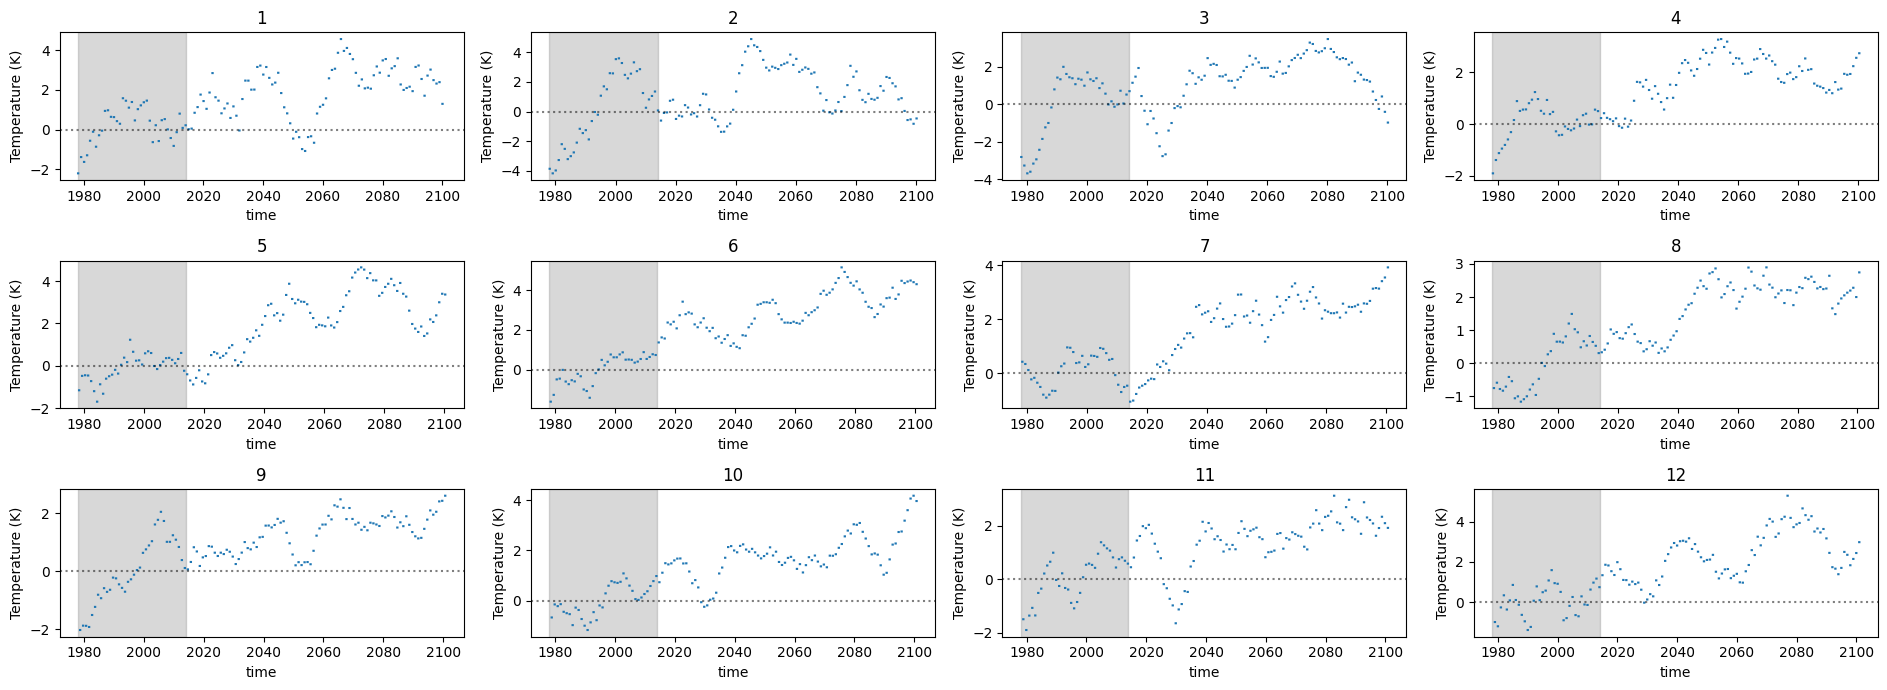

In [14]:
scenario = "ssp245"

plt.figure(figsize=(19, 7))
for m in np.arange(1, 13):
    plt.subplot(3, 4, m)
    (
        dict_all[scenario + "_trend"][:, 8, 8].where(
            dict_all[scenario + "_trend"]["time.month"] == m
        )
    ).plot()
    plt.title(m)
    plt.ylabel("Temperature (K)")
    plt.axvspan(
        "1978-01-01T00:00:00.000000000",
        "2014-01-01T00:00:00.000000000",
        color="gray",
        alpha=0.3,
    )
    plt.axhline(y=0, linestyle=":", color="black", alpha=0.5)
plt.tight_layout()

### Subset to years for training and predicting

In [15]:
for key, ds in dict_all.items():
    if "era" in key:
        time_period = "train"
    if "ssp245" in key:
        time_period = "predict"
    if "model_hist" in key:
        time_period = "train"

    dict_all[key] = downscaling_utils.subset_time(
        da=ds, run_parameters=RUN_PARAMETERS, time_period=time_period
    )

### Make plots looking at monthly trends

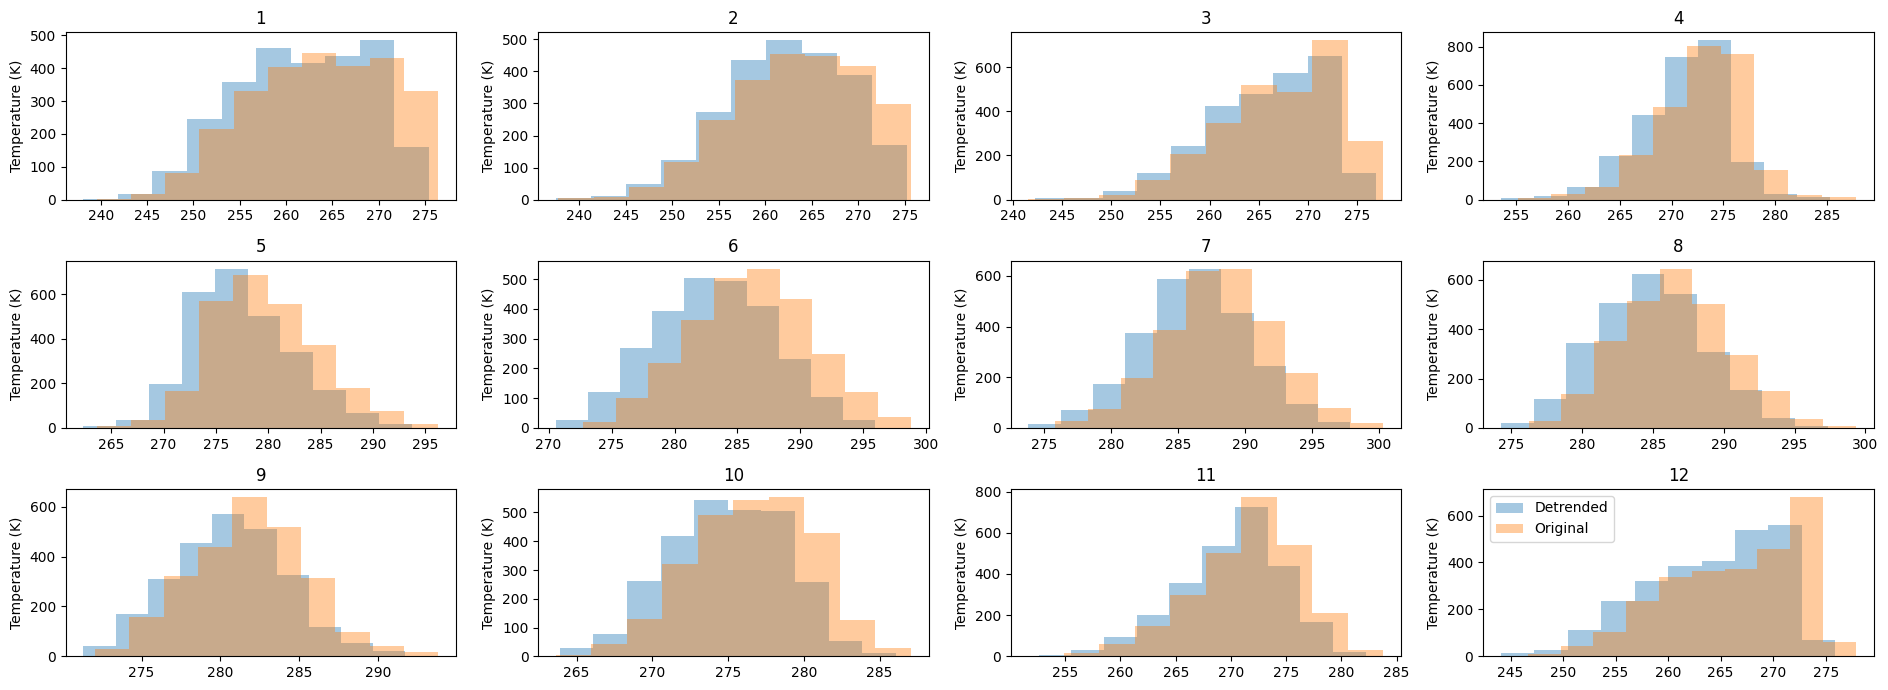

In [16]:
plt.figure(figsize=(19, 7))
for m in np.arange(1, 13):
    plt.subplot(3, 4, m)
    plt.hist(
        dict_all[scenario + "_detrended"][:, 8, 8].where(
            dict_all[scenario + "_detrended"]["time.month"] == m
        ),
        alpha=0.4,
        label="Detrended",
    )
    plt.hist(
        dict_all[scenario][:, 8, 8].where(dict_all[scenario]["time.month"] == m),
        alpha=0.4,
        label="Original",
    )
    plt.title(m)
    plt.ylabel("Temperature (K)")
plt.tight_layout()
plt.legend()

/tmp/ipykernel_65070/762100849.py:6: DeprecationWarning: Reductions are applied along the rolling dimension(s) '['time']'. Passing the 'dim' kwarg to reduction operations has no effect.
  .mean(dim="time")
/tmp/ipykernel_65070/762100849.py:9: DeprecationWarning: Reductions are applied along the rolling dimension(s) '['time']'. Passing the 'dim' kwarg to reduction operations has no effect.
  (dict_all[scenario][:, 8, 8].rolling(time=365 * 5).mean(dim="time").plot())
/tmp/ipykernel_65070/762100849.py:11: DeprecationWarning: Reductions are applied along the rolling dimension(s) '['time']'. Passing the 'dim' kwarg to reduction operations has no effect.
  (dict_all[scenario + "_trend"][:, 0, 0].rolling(time=365 * 5).mean(dim="time").plot())


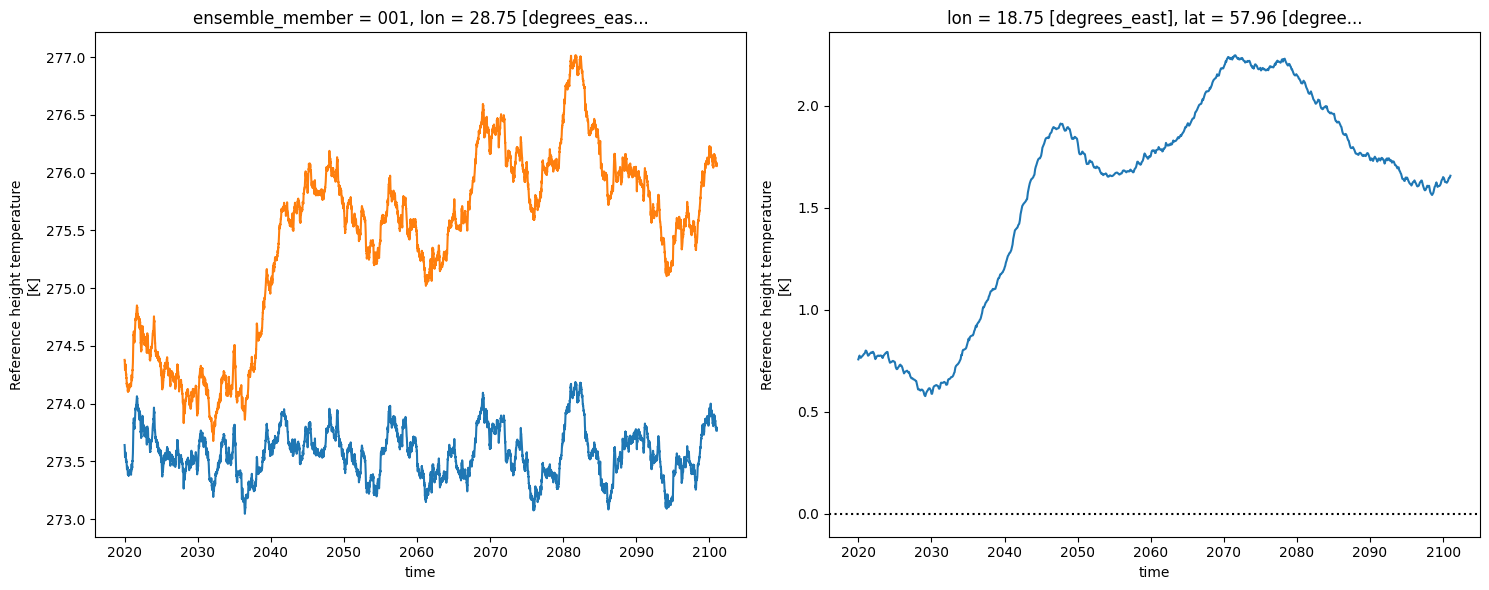

In [17]:
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
(dict_all[scenario + "_detrended"][:, 8, 8].rolling(time=365 * 5).mean(dim="time").plot())
(dict_all[scenario][:, 8, 8].rolling(time=365 * 5).mean(dim="time").plot())
plt.subplot(1, 2, 2)
(dict_all[scenario + "_trend"][:, 0, 0].rolling(time=365 * 5).mean(dim="time").plot())
plt.axhline(y=0, linestyle=":", color="k")
plt.tight_layout()

# Compare how different ways of detrending affects bias correction step

In [18]:
debiaser_v1 = QuantileMapping.from_variable(
    variable="tas",
    mapping_type="parametric",
    detrending="no_detrending",
    running_window_mode=True,
    running_window_length=31,
    running_window_step_length=1,
    running_window_mode_over_years_of_cm_future=False,
)
debiaser_v2 = QuantileMapping.from_variable(
    variable="tas",
    mapping_type="parametric",
    detrending="additive",
    running_window_mode=True,
    running_window_length=31,
    running_window_step_length=1,
    running_window_mode_over_years_of_cm_future=False,
)

tas_cm_hist_debiased_v1 = debiaser_v1.apply(
    obs=dict_all["era5_coarse"].values,
    cm_hist=dict_all["model_hist"].values,
    cm_future=dict_all["ssp245"].values,
    time_obs=dict_all["era5_coarse"]["time"].values,
    time_cm_hist=dict_all["model_hist"]["time"].values,
)

tas_cm_hist_debiased_v2 = debiaser_v2.apply(
    obs=dict_all["era5_coarse"].values,
    cm_hist=dict_all["model_hist"].values,
    cm_future=dict_all["ssp245"].values,
    time_obs=dict_all["era5_coarse"]["time"].values,
    time_cm_hist=dict_all["model_hist"]["time"].values,
)

tas_cm_hist_debiased_v3_anoms = debiaser_v1.apply(
    obs=dict_all["era5_coarse"].values,
    cm_hist=dict_all["model_hist"].values,
    cm_future=dict_all["ssp245_detrended"].values,
    time_obs=dict_all["era5_coarse"]["time"].values,
    time_cm_hist=dict_all["model_hist"]["time"].values,
)

tas_cm_hist_debiased_v3 = tas_cm_hist_debiased_v3_anoms + dict_all["ssp245_trend"]

  0%|          | 0/180 [00:00<?, ?it/s]/opt/coiled/env/lib/python3.13/site-packages/ibicus/debias/_debiaser.py:387: UserWarning: Debiaser runs without time-information for at least one of obs, cm_hist or cm_future.
                        This information is inferred, assuming the first observation is on a January 1st. Observations are chunked according to the assumed time information.
                        This might lead to slight numerical differences to the run with time information, however the debiasing is not fundamentally changed.
  return func(obs, cm_hist, cm_future, **kwargs)
100%|██████████| 180/180 [00:53<00:00,  3.37it/s]


In [19]:
tas_cm_hist_debiased_v1 = xr.DataArray(
    data=tas_cm_hist_debiased_v1,
    coords={
        "lat": dict_all["ssp245"]["lat"],
        "lon": dict_all["ssp245"]["lon"],
        "time": dict_all["ssp245"]["time"],
    },
    dims=["time", "lat", "lon"],
)

tas_cm_hist_debiased_v2 = xr.DataArray(
    data=tas_cm_hist_debiased_v2,
    coords={
        "lat": dict_all["ssp245"]["lat"],
        "lon": dict_all["ssp245"]["lon"],
        "time": dict_all["ssp245"]["time"],
    },
    dims=["time", "lat", "lon"],
)

tas_cm_hist_debiased_v3 = xr.DataArray(
    data=tas_cm_hist_debiased_v3,
    coords={
        "lat": dict_all["ssp245"]["lat"],
        "lon": dict_all["ssp245"]["lon"],
        "time": dict_all["ssp245"]["time"],
    },
    dims=["time", "lat", "lon"],
)

tas_cm_hist_debiased_v3_anoms = xr.DataArray(
    data=tas_cm_hist_debiased_v3_anoms,
    coords={
        "lat": dict_all["ssp245"]["lat"],
        "lon": dict_all["ssp245"]["lon"],
        "time": dict_all["ssp245"]["time"],
    },
    dims=["time", "lat", "lon"],
)

### Plots looking at differences between bias correction choices

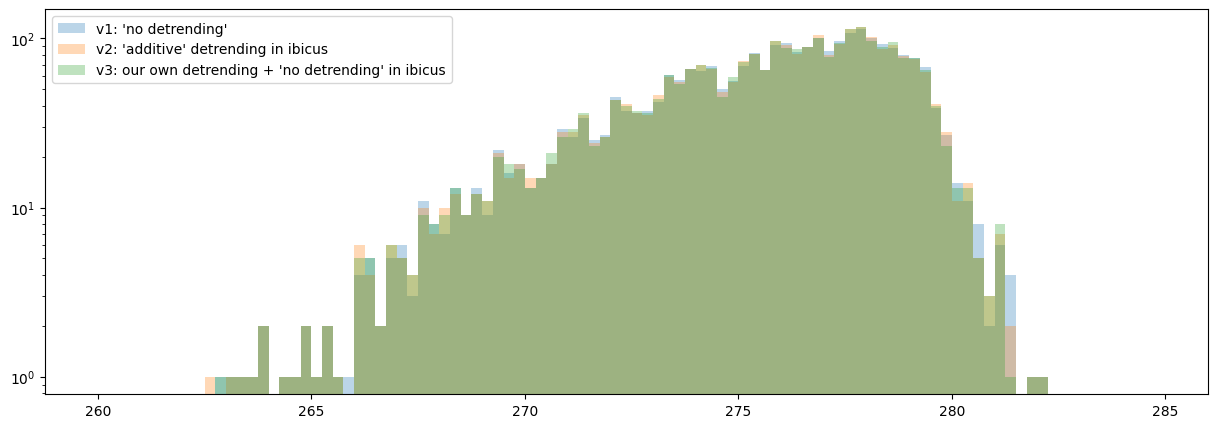

In [40]:
plt.figure(figsize=(15, 5))
plt.hist(
    tas_cm_hist_debiased_v1.where(tas_cm_hist_debiased_v1["time.month"] == 1)[:, 0, 0],
    bins=np.arange(260, 285, 0.25),
    alpha=0.3,
    label="v1: 'no detrending'",
)
plt.hist(
    tas_cm_hist_debiased_v2.where(tas_cm_hist_debiased_v2["time.month"] == 1)[:, 0, 0],
    alpha=0.3,
    bins=np.arange(260, 285, 0.25),
    label="v2: 'additive' detrending in ibicus",
)
plt.hist(
    tas_cm_hist_debiased_v3.where(tas_cm_hist_debiased_v3["time.month"] == 1)[:, 0, 0],
    alpha=0.3,
    bins=np.arange(260, 285, 0.25),
    label="v3: our own detrending + 'no detrending' in ibicus",
)
plt.yscale("log")
plt.legend()

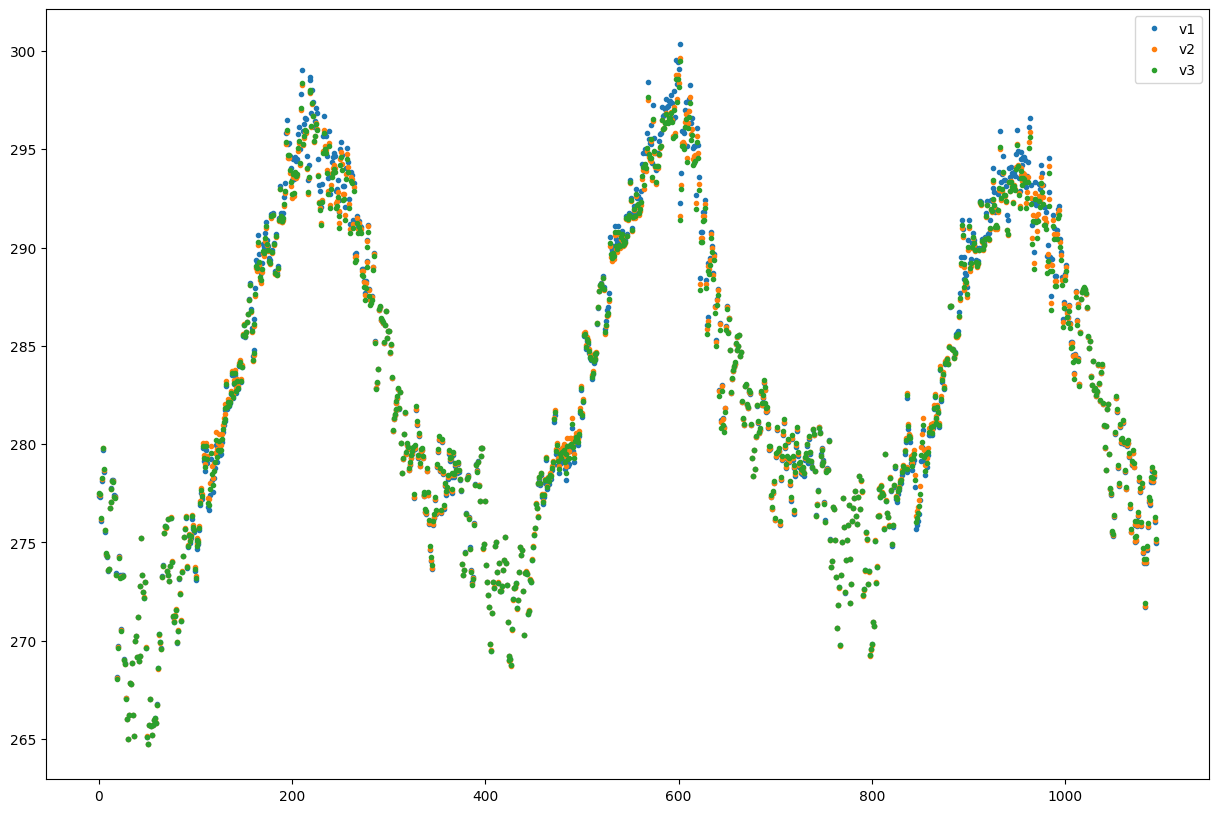

In [33]:
plt.figure(figsize=(15, 10))
plt.plot(tas_cm_hist_debiased_v1[-365 * 3 :, 0, 0], ".", label="v1")
plt.plot(tas_cm_hist_debiased_v2[-365 * 3 :, 0, 0], ".", label="v2")
plt.plot(tas_cm_hist_debiased_v3[-365 * 3 :, 0, 0], ".", label="v3")
# plt.plot(tas_cm_hist_debiased_v3_anoms[-500:, 0, 0], ".", label="v3")
plt.legend()

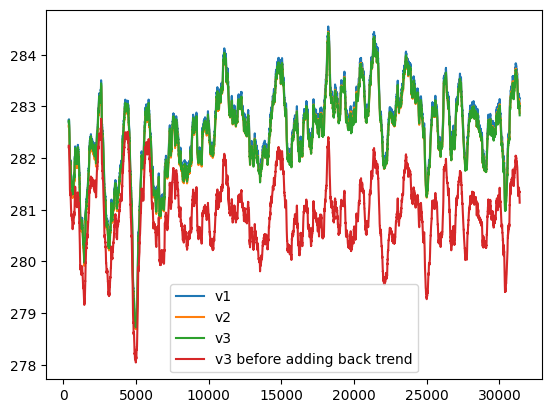

In [26]:
plt.plot(tas_cm_hist_debiased_v1[:, 0, 0].rolling(time=365).mean(), label="v1")
plt.plot(tas_cm_hist_debiased_v2[:, 0, 0].rolling(time=365).mean(), label="v2")
plt.plot(tas_cm_hist_debiased_v3[:, 0, 0].rolling(time=365).mean(), label="v3")
plt.plot(
    tas_cm_hist_debiased_v3_anoms[:, 0, 0].rolling(time=365).mean(),
    label="v3 before adding back trend",
)
plt.legend()

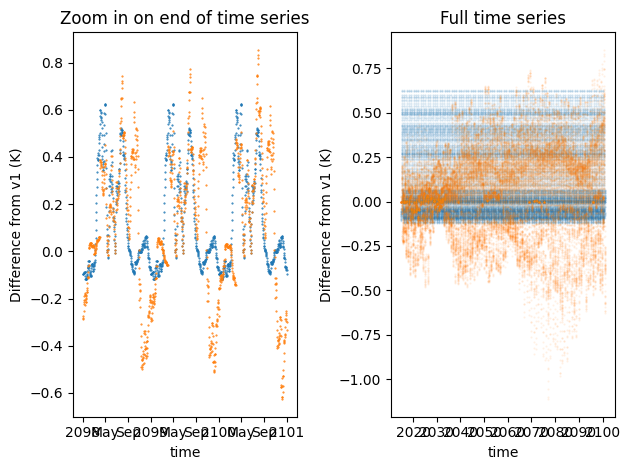

In [31]:
plt.subplot(1, 2, 1)
(tas_cm_hist_debiased_v2[-365 * 3 :, 8, 8] - tas_cm_hist_debiased_v1[-365 * 3 :, 8, 8]).plot(
    marker=".", linewidth=0, alpha=1, markersize=1
)
(tas_cm_hist_debiased_v3[-365 * 3 :, 8, 8] - tas_cm_hist_debiased_v1[-365 * 3 :, 8, 8]).plot(
    marker=".", linewidth=0, alpha=1, markersize=1
)
plt.ylabel("Difference from v1 (K)")
plt.title("Zoom in on end of time series")

plt.subplot(1, 2, 2)
(tas_cm_hist_debiased_v2[:, 8, 8] - tas_cm_hist_debiased_v1[:, 8, 8]).plot(
    marker=".", linewidth=0, alpha=0.1, markersize=1
)
(tas_cm_hist_debiased_v3[:, 8, 8] - tas_cm_hist_debiased_v1[:, 8, 8]).plot(
    marker=".", linewidth=0, alpha=0.1, markersize=1
)
plt.ylabel("Difference from v1 (K)")
plt.title("Full time series")
plt.tight_layout()

In [30]:
print("Max effect of detrending on any single day")
print(np.nanmax(tas_cm_hist_debiased_v3 - tas_cm_hist_debiased_v1))
print(np.nanmin(tas_cm_hist_debiased_v3 - tas_cm_hist_debiased_v1))

Max effect of detrending on any single day
2.69693
-2.314331


### Demo CDF figures for high end of distribution

In [28]:
value = np.percentile(dict_all["ssp245"].values[:, 8, 8], 99.99)
idx = np.argmin(np.abs(dict_all["ssp245"].values[:, 8, 8] - value))
print(idx)

print("Original value")
print(dict_all["ssp245"].values[idx, 8, 8])
print("Original detrended value")
print(dict_all["ssp245_detrended"].values[idx, 8, 8])
print("Debiased value #1")
print(tas_cm_hist_debiased_v1.values[idx, 8, 8])
print("Debiased value #2")
print(tas_cm_hist_debiased_v2.values[idx, 8, 8])
print("Detrended value for approach #3 before adding trend back in")
print(tas_cm_hist_debiased_v3_anoms.values[idx, 8, 8])
print("Debiased value #3 (final val)")
print(tas_cm_hist_debiased_v3.values[idx, 8, 8])

14448
Original value
299.11395
Original detrended value
297.12585
Debiased value #1
298.75848
Debiased value #2
299.07056
Detrended value for approach #3 before adding trend back in
297.15524
Debiased value #3 (final val)
299.14334


(0.9, 1.01)

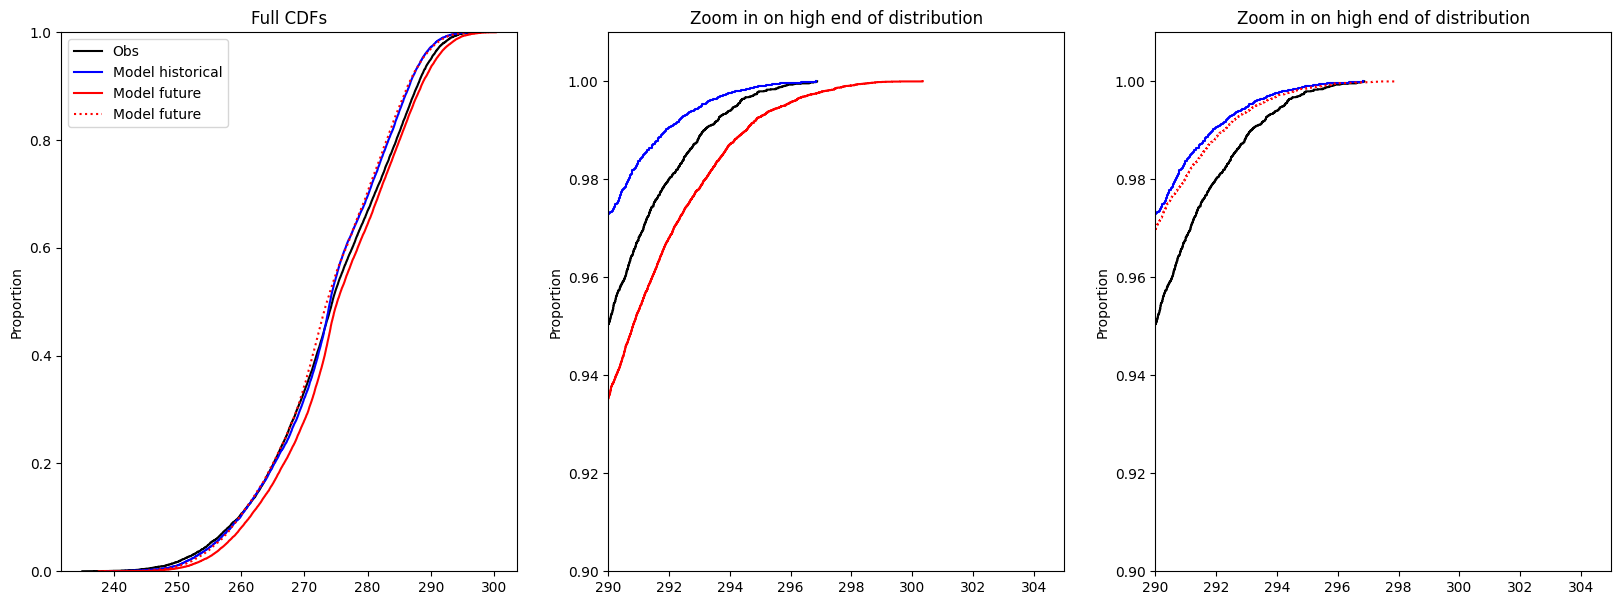

In [21]:
plt.figure(figsize=(20, 7))
plt.subplot(1, 3, 1)
plt.title("Full CDFs")
sns.ecdfplot(data=dict_all["era5_coarse"].values[:, 8, 8], label="Obs", color="k")
sns.ecdfplot(data=dict_all["model_hist"].values[:, 8, 8], label="Model historical", color="b")
sns.ecdfplot(data=dict_all["ssp245"].values[:, 8, 8], label="Model future", color="r")
sns.ecdfplot(
    data=dict_all["ssp245_detrended"].values[:, 8, 8],
    label="Model future",
    color="r",
    linestyle=":",
)
plt.legend()
plt.subplot(1, 3, 2)
plt.title("Zoom in on high end of distribution")
sns.ecdfplot(data=dict_all["era5_coarse"].values[:, 8, 8], label="Obs", color="k")
sns.ecdfplot(data=dict_all["model_hist"].values[:, 8, 8], label="Model historical", color="b")
sns.ecdfplot(data=dict_all["ssp245"].values[:, 8, 8], label="Model future", color="r")
plt.xlim([290, 305])
plt.ylim([0.9, 1.01])

plt.subplot(1, 3, 3)
plt.title("Zoom in on high end of distribution")
sns.ecdfplot(data=dict_all["era5_coarse"].values[:, 8, 8], label="Obs", color="k")
sns.ecdfplot(data=dict_all["model_hist"].values[:, 8, 8], label="Model historical", color="b")
sns.ecdfplot(
    data=dict_all["ssp245_detrended"].values[:, 8, 8],
    label="Model future",
    color="r",
    linestyle=":",
)
plt.xlim([290, 305])
plt.ylim([0.9, 1.01])